In [1]:
from langgraph.graph import StateGraph, START ,END
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explaination: str

In [3]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

In [ ]:
HF_API_KEY=

In [6]:
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",  
    task="text-generation",
    max_new_tokens=512,
    huggingfacehub_api_token=HF_API_KEY,
)

model = ChatHuggingFace(llm=llm)


In [ ]:
def generate_joke(state:JokeState):
    prompt = f"Generate a joke on the topic {state['topic']}."

    response = model.invoke(prompt).content
    return {"joke":response}

In [8]:
def generate_joke_explanation(state:JokeState):
    prompt = f" explain the joke for the topic {state['joke']} ."
    response = model.invoke(prompt).content
    return {"explaination":response}

In [10]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke",generate_joke)
graph.add_node("generate_joke_explanation",generate_joke_explanation)

graph.add_edge(START,"generate_joke")
graph.add_edge('generate_joke',"generate_joke_explanation")
graph.add_edge('generate_joke_explanation',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)


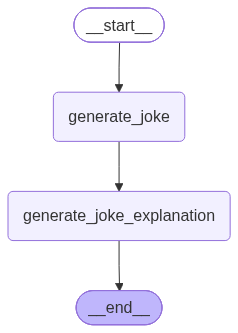

In [12]:
workflow

In [17]:
config = {'configurable':{'thread_id':'1'}}

workflow.invoke({'topic':'dog'},config=config)

{'topic': 'dog',
 'joke': AIMessage(content="Why did the dog join the jazz band?\n\nBecause he was a wag-in' drummer!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 37, 'total_tokens': 56}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01031-0a3f-7273-b4cc-05c3f3460b62-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 19, 'total_tokens': 56}),
 'explaination': 'This joke is a play on words. The phrase "wag-in\' drummer" puns on two meanings of "wag." In this context, it combines "wag" (meaning to move back and forth quickly) with "wag" (as in a skilled or enthusiastic performer). \n\nThe joke humorously explains why a dog would join a jazz band by saying the dog is an excellent drummer because it wags its tail a lot. It\'s a lighthearted and clever wordplay that ties the dog\'s physical trait (wagging its t

In [19]:
config1 = {'configurable':{'thread_id':'1'}}

workflow.invoke({'topic':'pasta'},config=config1)

{'topic': 'pasta',
 'joke': AIMessage(content='Why did the pasta go to the doctor?\n\nBecause it had a noodle-laryngitis and couldn\'t "spaghetti" right!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 37, 'total_tokens': 66}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01031-2586-77a1-9ff5-8db72a3b3f22-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 29, 'total_tokens': 66}),
 'explaination': 'This joke is a play on words. The pasta is pretending to be a person who went to the doctor because it was sick. However, the punchline "couldn\'t \'spaghetti\' right!" is a pun, where "spaghetti" is used not as the noun referring to the food but as a verb, meaning to talk or communicate. So, the pasta (in a personified form) is saying it couldn\'t speak properly because it had a sore throat (noodle-laryngitis).'}

In [14]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'dogs', 'joke': AIMessage(content='Why did the dog join the book club? \n\nBecause he wanted to get chewed on some great literature!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 37, 'total_tokens': 60}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0102d-e33b-7bf1-89c6-fd883d4199b7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 23, 'total_tokens': 60}), 'explaination': 'This joke is a play on words and a pun. The setup is that the dog joined a book club, which is typically a group that meets to discuss books. The punchline, "Because he wanted to get chewed on some great literature!" is a clever double meaning. On one hand, it refers to the typical book club activity of discussing literature. On the other hand, it humorously plays on the dog\'s natural behavior of chewing 

In [20]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content='Why did the pasta go to the doctor?\n\nBecause it had a noodle-laryngitis and couldn\'t "spaghetti" right!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 37, 'total_tokens': 66}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01031-2586-77a1-9ff5-8db72a3b3f22-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 29, 'total_tokens': 66}), 'explaination': 'This joke is a play on words. The pasta is pretending to be a person who went to the doctor because it was sick. However, the punchline "couldn\'t \'spaghetti\' right!" is a pun, where "spaghetti" is used not as the noun referring to the food but as a verb, meaning to talk or communicate. So, the pasta (in a personified form) is saying it couldn\'t speak properly because it had a sore throat (no

In [21]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pasta', 'joke': AIMessage(content='Why did the pasta go to the doctor?\n\nBecause it had a noodle-laryngitis and couldn\'t "spaghetti" right!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 37, 'total_tokens': 66}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01031-2586-77a1-9ff5-8db72a3b3f22-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 29, 'total_tokens': 66}), 'explaination': 'This joke is a play on words. The pasta is pretending to be a person who went to the doctor because it was sick. However, the punchline "couldn\'t \'spaghetti\' right!" is a pun, where "spaghetti" is used not as the noun referring to the food but as a verb, meaning to talk or communicate. So, the pasta (in a personified form) is saying it couldn\'t speak properly because it had a sore throat (no

In [22]:
config2 = {'configurable':{'thread_id':'3'}}
workflow.invoke({'topic':'cats'},config=config2)

{'topic': 'cats',
 'joke': AIMessage(content="Sure, here's a kitty cat joke for you:\n\nWhy don't cats play poker in the jungle?\n\nBecause there are too many cheetahs!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 37, 'total_tokens': 69}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01032-8e18-7d13-bd3b-7ff47cce6446-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 32, 'total_tokens': 69}),
 'explaination': 'This joke is a play on words and a common card game scenario. The setup asks why cats don\'t play poker in the jungle. The punchline "Because there are too many cheetahs!" is a pun, where "cheetahs" sounds like "cheaters," which are people who might cheat at the game of poker. So the joke is humorously suggesting that with too many cheaters around, the cats wouldn\'t want to play poker in the jungle.

In [24]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'cats', 'joke': AIMessage(content="Sure, here's a kitty cat joke for you:\n\nWhy don't cats play poker in the jungle?\n\nBecause there are too many cheetahs!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 37, 'total_tokens': 69}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01032-8e18-7d13-bd3b-7ff47cce6446-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 32, 'total_tokens': 69}), 'explaination': 'This joke is a play on words and a common card game scenario. The setup asks why cats don\'t play poker in the jungle. The punchline "Because there are too many cheetahs!" is a pun, where "cheetahs" sounds like "cheaters," which are people who might cheat at the game of poker. So the joke is humorously suggesting that with too many cheaters around, the cats wouldn\'t want to play 

In [29]:
config3 = {'configurable':{'thread_id':'11'}}
workflow.invoke({"topic":"pizza"},config=config3)

{'topic': 'pizza',
 'joke': AIMessage(content='Why was the pizza late to the party? Because it got lost in the crust!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 37, 'total_tokens': 55}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0104a-fe89-79c1-9710-e3587e0c702e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 18, 'total_tokens': 55}),
 'explaination': 'The joke plays on the double meaning of "crust." In this context, it\'s a play on words: the pizza\'s crust is a part of the pizza itself, but the phrase "got lost in the crust" can also mean the pizza was delayed or missing at the party. It\'s a clever wordplay that combines a physical aspect of the pizza with a pun about being late.'}

In [30]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content='Why was the pizza late to the party? Because it got lost in the crust!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 37, 'total_tokens': 55}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0104a-fe89-79c1-9710-e3587e0c702e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 18, 'total_tokens': 55}), 'explaination': 'The joke plays on the double meaning of "crust." In this context, it\'s a play on words: the pizza\'s crust is a part of the pizza itself, but the phrase "got lost in the crust" can also mean the pizza was delayed or missing at the party. It\'s a clever wordplay that combines a physical aspect of the pizza with a pun about being late.'}, next=(), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f

Time Travel

In [31]:
workflow.get_state_history({'configurable':{'thread_id':'11','checkpoint_id':'1f19a4e8-4f76-637d-bfff-15b522d62ded'}})

<generator object Pregel.get_state_history at 0x000001C90E1F9850>

In [34]:
workflow.invoke(None,{'configurable':{'thread_id':'11','checkpoint_id':'1f19a4ee-73fa-67e9-8001-3909302589e4'}})

{'topic': 'pizza',
 'joke': AIMessage(content="Sure! Here's a pizza joke for you:\n\nWhy did the pizza go to the doctor?\n\nBecause it was feeling a little crust-asic!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 37, 'total_tokens': 67}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0104e-382f-7d10-9f1f-7d2e7e6ad723-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 30, 'total_tokens': 67}),
 'explaination': 'This pizza joke is a play on words. The punchline "because it was feeling a little crust-asic" is a pun, combining the word "crust" (a characteristic part of a pizza) with the term "crusty," which sounds similar to "crusty" as in old or boring. The joke implies the pizza was feeling a bit "crusty" or old, which is a funny way to describe a pizza visiting a doctor.'}

In [35]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content="Sure! Here's a pizza joke for you:\n\nWhy did the pizza go to the doctor?\n\nBecause it was feeling a little crust-asic!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 37, 'total_tokens': 67}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0104e-382f-7d10-9f1f-7d2e7e6ad723-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 30, 'total_tokens': 67}), 'explaination': 'This pizza joke is a play on words. The punchline "because it was feeling a little crust-asic" is a pun, combining the word "crust" (a characteristic part of a pizza) with the term "crusty," which sounds similar to "crusty" as in old or boring. The joke implies the pizza was feeling a bit "crusty" or old, which is a funny way to describe a pizza visiting a doctor.'}, next=(), confi

In [40]:
#update 
workflow.update_state({'configurable':{'thread_id':'11','checkpoint_id':'1f19a4e8-4f7d-68cc-8000-64b2f9550565','checkpoint_ns':''}},{"topic":"samosa"})

{'configurable': {'thread_id': '11',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19a4fb-310d-633c-8001-bcad49bbfc9a'}}

In [41]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f19a4fb-310d-633c-8001-bcad49bbfc9a'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-08-17T15:24:12.251423+00:00', parent_config={'configurable': {'thread_id': '11', 'checkpoint_ns': '', 'checkpoint_id': '1f19a4e8-4f7d-68cc-8000-64b2f9550565'}}, tasks=(PregelTask(id='260a5dc8-b021-64db-508d-0fba93482543', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content="Sure! Here's a pizza joke for you:\n\nWhy did the pizza go to the doctor?\n\nBecause it was feeling a little crust-asic!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 37, 'total_tokens': 67}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint':

In [43]:
workflow.invoke(None,{'configurable':{'thread_id':'11','checkpoint_id':'1f19a4fb-310d-633c-8001-bcad49bbfc9a'}})

{'topic': 'samosa',
 'joke': AIMessage(content='Why did the samosa cross the road? \n\nTo get to the curry on the other side!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 38, 'total_tokens': 59}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01054-2ae7-7402-bd15-b84f9196da91-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 21, 'total_tokens': 59}),
 'explaination': 'This joke is a play on words, using the structure of a classic riddle or joke format. The setup is: "Why did the samosa cross the road?" The punchline, "To get to the curry on the other side!" is a bit of a pun because a samosa is a food item that can\'t literally cross a road, but the word "curry" is associated with food and particularly with the flavor of the filling in a samosa. The joke humorously implies that the samosa is seeking out mo

In [44]:
list(workflow.get_state_history(config3))

[StateSnapshot(values={'topic': 'samosa', 'joke': AIMessage(content='Why did the samosa cross the road? \n\nTo get to the curry on the other side!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 38, 'total_tokens': 59}, 'model_name': 'Qwen/Qwen2.5-7B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a01054-2ae7-7402-bd15-b84f9196da91-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 21, 'total_tokens': 59}), 'explaination': 'This joke is a play on words, using the structure of a classic riddle or joke format. The setup is: "Why did the samosa cross the road?" The punchline, "To get to the curry on the other side!" is a bit of a pun because a samosa is a food item that can\'t literally cross a road, but the word "curry" is associated with food and particularly with the flavor of the filling in a samosa. The joke humorously implies that the samo